# Zadanie 2. Grupowanie produktów magazynowych - Gaussian Mixture Model (GMM)

> **Raport końcowy** znajduje się na końcu notebooka.

## Import bibliotek

In [255]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')
sns.set_theme()

## Wczytanie danych

In [256]:
df_raw = pd.read_excel('sku_data.xlsx')
print('Wymiar:', df_raw.shape)
df_raw.head()

Wymiar: (2279, 8)


,ID,Unitprice,Expire date,Outbound number,Total outbound,Pal grossweight,Pal height,Units per pal
0,1,0.058,547,9,2441.0,105.60,1.56,1920
1,2,0.954,547,0,0.0,207.68,1.00,384
2,3,2.385,547,12,23.0,165.78,1.02,108
3,4,5.100,547,0,0.0,221.04,1.05,72
4,5,0.000,547,0,0.0,0.00,0.00,0


In [257]:
df = df_raw.drop(columns=['ID']).copy()
print('Wymiar po usunięciu ID:', df.shape)
df.head()

Wymiar po usunięciu ID: (2279, 7)


,Unitprice,Expire date,Outbound number,Total outbound,Pal grossweight,Pal height,Units per pal
0,0.058,547,9,2441.0,105.60,1.56,1920
1,0.954,547,0,0.0,207.68,1.00,384
2,2.385,547,12,23.0,165.78,1.02,108
3,5.100,547,0,0.0,221.04,1.05,72
4,0.000,547,0,0.0,0.00,0.00,0


## Eksploracja danych

In [258]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2279 entries, 0 to 2278
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unitprice        2279 non-null   float64
 1   Expire date      2279 non-null   int64  
 2   Outbound number  2279 non-null   int64  
 3   Total outbound   2279 non-null   float64
 4   Pal grossweight  2279 non-null   float64
 5   Pal height       2279 non-null   float64
 6   Units per pal    2279 non-null   int64  
dtypes: float64(4), int64(3)
memory usage: 124.8 KB


In [259]:
df.isnull().sum()

Unitprice          0
Expire date        0
Outbound number    0
Total outbound     0
Pal grossweight    0
Pal height         0
Units per pal      0
dtype: int64

In [260]:
df.describe()

,Unitprice,Expire date,Outbound number,Total outbound,Pal grossweight,Pal height,Units per pal
count,2279.000000,2279.000000,2279.000000,2279.000000,2279.000000,2279.000000,2279.000000
mean,4.269402,410.371654,235.976305,731.701053,192.939582,0.672798,755.563405
std,14.449000,240.875419,700.230685,2146.029848,164.616813,0.552117,6278.437915
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,365.000000,0.000000,0.000000,60.000000,0.000000,32.000000
50%,1.293800,547.000000,1.000000,3.000000,167.680000,0.840000,108.000000
75%,4.545000,547.000000,45.000000,419.500000,277.560000,1.020000,384.000000
max,518.592000,734.000000,6325.000000,26411.000000,907.200000,2.160000,200000.000000


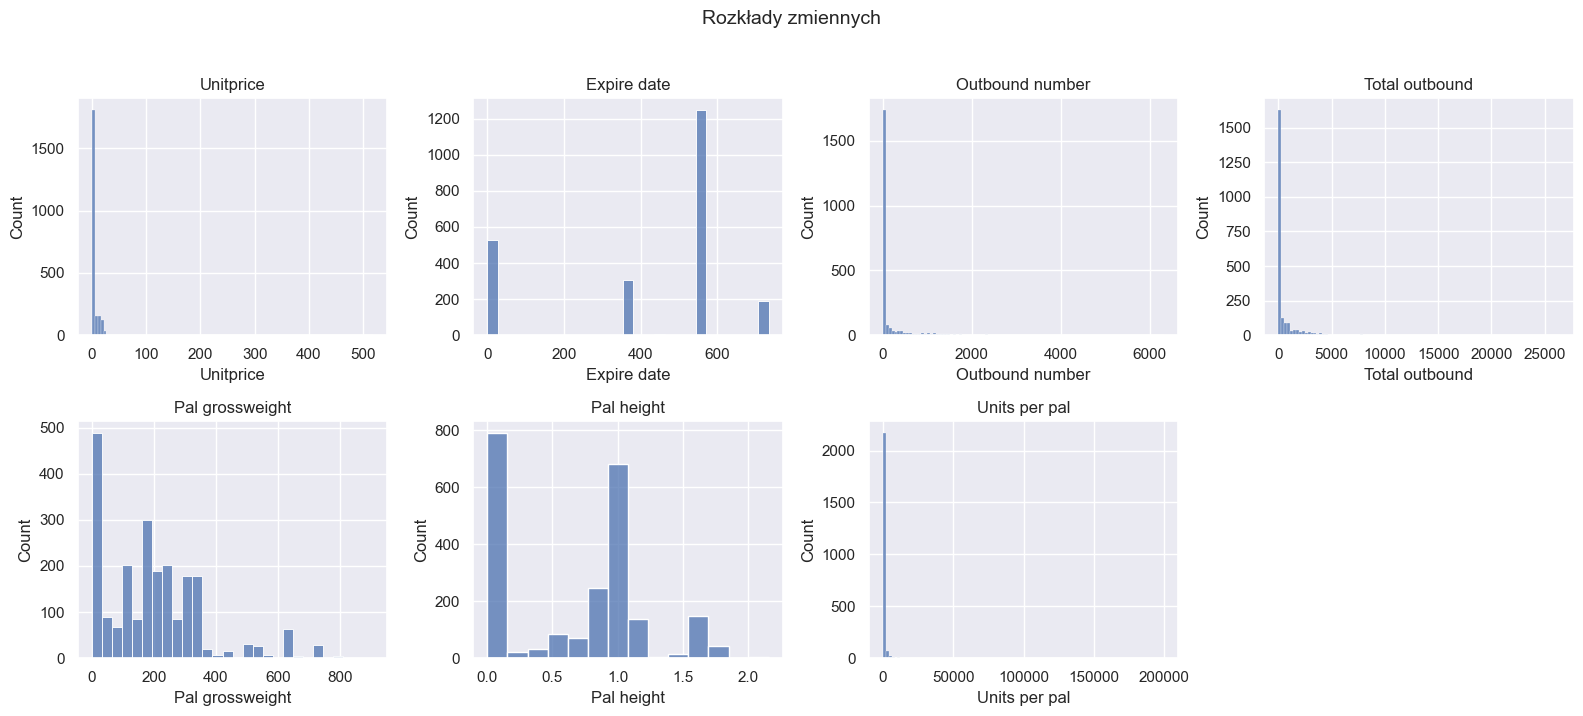

In [261]:
# Histogramy wszystkich zmiennych
num_cols = df.columns.tolist()
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.flatten(), num_cols):
    sns.histplot(df[col].dropna(), ax=ax)
    ax.set_title(col)
for ax in axes.flatten()[len(num_cols):]:
    ax.axis('off')
fig.suptitle('Rozkłady zmiennych', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

#### Na wykresach widać:

**Unitprice** Zdecydowana większość produktów ma cenę bliską 0. Muszę to zbadać.

**Outbound number** i **Total outbound** bardzo podobny wzorzec co **Unitprice**: masa wartości przy 0. Myslę, że między zmiennymi może być silna korelacja, sprawdzę korelację na heatmapie.

**Units per pal**, największy outlier spośród wszystkich zmiennych.

**Pal grossweight** Widzę prawoskośność.

**Expire date** przypomina zmienna dyskretna.

*Wnioski:* Zastosuję `np.log1p` na `Unitprice`, `Units per pal`. W przypadku `Unitprice`, `Outbound number` i `Total outbound` zbadam zera.

In [262]:
# Analiza zer w Unitprice, Outbound number i Total outbound
cols_zeros = ['Unitprice', 'Outbound number', 'Total outbound']
n = len(df)
print(f'Liczba wierszy: {n}\n')
print(f'{"Kolumna":<20} {"Liczba zer":>10} {"% zer":>8} {"Wartości < 1":>14}')
print('-' * 56)
for col in cols_zeros:
    zeros = (df[col] == 0).sum()
    below_one = (df[col] < 1).sum()
    print(f'{col:<20} {zeros:>10} {zeros/n*100:>7.1f}% {below_one:>14}')

Liczba wierszy: 2279

Kolumna              Liczba zer    % zer   Wartości < 1
--------------------------------------------------------
Unitprice                   710    31.2%           1081
Outbound number             979    43.0%            979
Total outbound              979    43.0%            979


In [263]:
# Czy produkty z ceną 0 były kiedykolwiek wysyłane?
mask_zero_price = df['Unitprice'] == 0
print(df[mask_zero_price][['Outbound number', 'Total outbound']].describe())

# Czy zera w outbound to te same wiersze co zera w unitprice?
print('---'*20)
print((mask_zero_price & (df['Outbound number'] == 0)).sum())

       Outbound number  Total outbound
count       710.000000      710.000000
mean          5.298592       99.640845
std          19.924777      370.216788
min           0.000000        0.000000
25%           0.000000        0.000000
50%           0.000000        0.000000
75%           1.000000        3.000000
max         300.000000     3641.000000
------------------------------------------------------------
498


**Unitprice = 0:** z analizy wynika, że 212 (710 - 498) produktów z ceną 0 miało aktywny outbound, czyli były wysyłane do klientów. Cena 0 to brakująca wartość w systemie, nie cecha produktu. Imputujemy medianą wartości dodatnich (nie globalną medianą, ponieważ prawdopodobnie byłaby ona zaburzona przez zera). Reszta jest nadal w magazynie, prawdopodobnie, ktoś zapomniał wpisać im ceny.

**Outbound number / Total outbound = 0:** dokładnie te same 979 wierszy mają oba outboundy równe 0. To martwy stock, produkty, które nigdy nie opuściły magazynu. Ta informacja jest wartościowa dla klasteryzacji. Nie imputujemy.

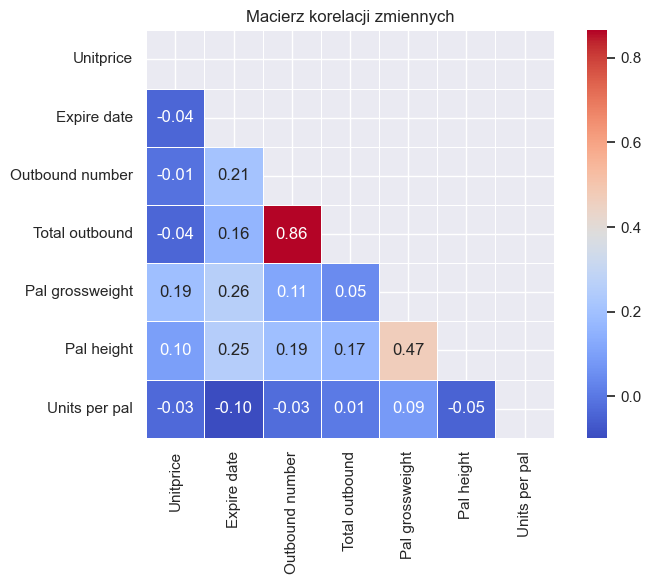

In [264]:
# Macierz korelacji
plt.figure(figsize=(8, 6))
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)
plt.title('Macierz korelacji zmiennych')
plt.tight_layout()
plt.show()

#### Obserwacje z macierzy korelacji:

**Outbound number** i **Total outbound: 0.86** - bardzo wysoka korelacja. Im więcej zamówień wychodzących, tym więcej wysłanych jednostek. Te dwie zmienne niosą prawie tę samą informację. Zastąpię je cechą pochodną `avg_units_per_order = Total outbound / (Outbound number + 1)` i usunę obie oryginalne kolumny.

## Inżynieria cech

`avg_units_per_order = Total outbound / (Outbound number + 1)`

Jest to **średnia liczba jednostek na jedno zamówienie wychodzące**. Produkt wysyłany rzadko ale w dużych partiach i produkt wysyłany często w małych ilościach mogą mieć podobne `Total outbound` i `Outbound number`, ale zupełnie inne `avg_units_per_order`.

In [265]:
# Zmienna pochodna, średnia liczba jednostek na zamówienie
df['avg_units_per_order'] = df['Total outbound'] / (df['Outbound number'] + 1)
df = df.drop(columns=['Outbound number', 'Total outbound'])
num_cols = df.columns.tolist()
print('Zmienne po inżynierii cech:', num_cols)

Zmienne po inżynierii cech: ['Unitprice', 'Expire date', 'Pal grossweight', 'Pal height', 'Units per pal', 'avg_units_per_order']


## Obsługa danych brakujących

Imputacja zerami dotyczy czterech zmiennych:

**Unitprice = 0** - omówione szczegółowo powyżej. Zastępujemy medianą wartości dodatnich.

**Pal grossweight = 0 i Pal height = 0** - produkt bez wagi i bez wysokości palety fizycznie nie istnieje. Podejście spójne z Unitprice: zera to braki w systemie, zastępujemy medianą wartości dodatnich.

**Expire date = 0** - data ważności równa 0 oznacza brak wpisu w systemie. Produkt bez terminu ważności nie może być poprawnie zaplanowany logistycznie. Zastępujemy medianą wartości dodatnich.

In [266]:
# Imputacja zer w Unitprice — medianą wartości dodatnich
median_nonzero_price = df[df['Unitprice'] > 0]['Unitprice'].median()
n_zeros_price = (df['Unitprice'] == 0).sum()
df['Unitprice'] = df['Unitprice'].replace(0, median_nonzero_price)
print(f'Unitprice: zastąpiono {n_zeros_price} zer medianą wartości dodatnich ({median_nonzero_price:.2f})')

# Imputacja zer w Pal grossweight, Pal height i expire date
for col in ['Pal grossweight', 'Pal height', 'Expire date']:
    median_nonzero = df[df[col] > 0][col].median()
    n_zeros = (df[col] == 0).sum()
    df[col] = df[col].replace(0, median_nonzero)
    print(f'{col}: zastąpiono {n_zeros} zer medianą wartości dodatnich ({median_nonzero:.2f})')

Unitprice: zastąpiono 710 zer medianą wartości dodatnich (2.80)
Pal grossweight: zastąpiono 371 zer medianą wartości dodatnich (207.68)
Pal height: zastąpiono 787 zer medianą wartości dodatnich (1.02)
Expire date: zastąpiono 529 zer medianą wartości dodatnich (547.00)


## Przygotowanie danych

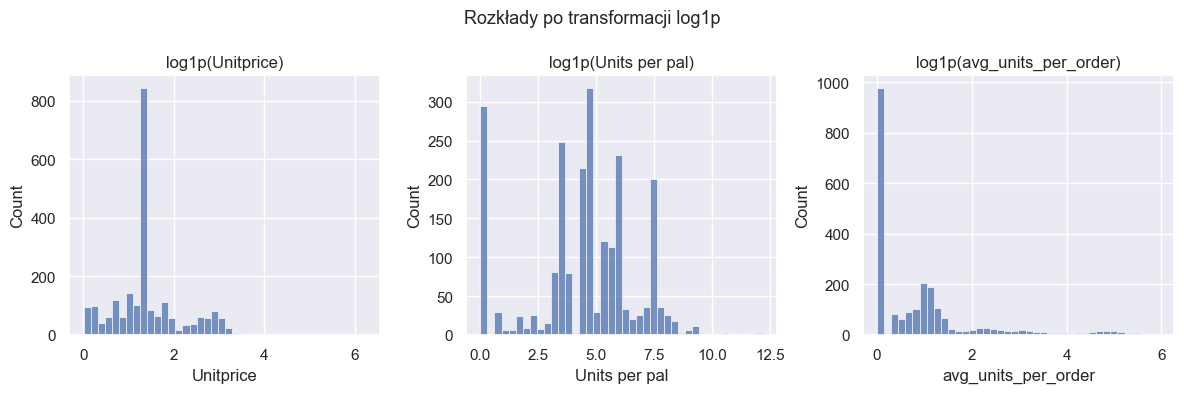

In [267]:
# Transformacja log1p dla zmiennych ze skośnym rozkładem
cols_log = ['Unitprice', 'Units per pal', 'avg_units_per_order']
df_log = df.copy()
df_log[cols_log] = np.log1p(df[cols_log])

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, col in zip(axes, cols_log):
    sns.histplot(df_log[col], ax=ax, bins=40)
    ax.set_title(f'log1p({col})')
fig.suptitle('Rozkłady po transformacji log1p', fontsize=13)
plt.tight_layout()
plt.show()

## Standaryzacja

In [268]:
# Standaryzacja na danych po transformacji log1p
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_log[num_cols])
print('Kształt macierzy cech po standaryzacji:', X_scaled.shape)

Kształt macierzy cech po standaryzacji: (2279, 6)


## Dobór liczby klastrów - AIC i BIC

**AIC (Akaike Information Criterion)** i **BIC (Bayesian Information Criterion)** to kryteria wyboru modelu, które równoważą dopasowanie do danych z jego złożonością. Im niższa wartość, tym lepszy model.

- **AIC** preferuje modele z lepszym dopasowaniem i może prowadzić do przeszacowania liczby klastrów.
- **BIC** silniej penalizuje złożoność (liczbę parametrów) — jest bardziej konserwatywny i zalecany przy wyborze liczby składowych GMM, gdyż zmniejsza ryzyko przeuczenia (overfitting).

In [269]:
ks   = range(2, 11)
aics = []
bics = []

for k in ks:
    gmm = GaussianMixture(n_components=k, covariance_type='full',
                          random_state=42, n_init=5)
    gmm.fit(X_scaled)
    aics.append(gmm.aic(X_scaled))
    bics.append(gmm.bic(X_scaled))
    labels = gmm.predict(X_scaled)

k_bic = list(ks)[int(np.argmin(bics))]
k_aic = list(ks)[int(np.argmin(aics))]
print(f'Optymalne k wg BIC:        {k_bic}')
print(f'Optymalne k wg AIC:        {k_aic}')

Optymalne k wg BIC:        10
Optymalne k wg AIC:        10


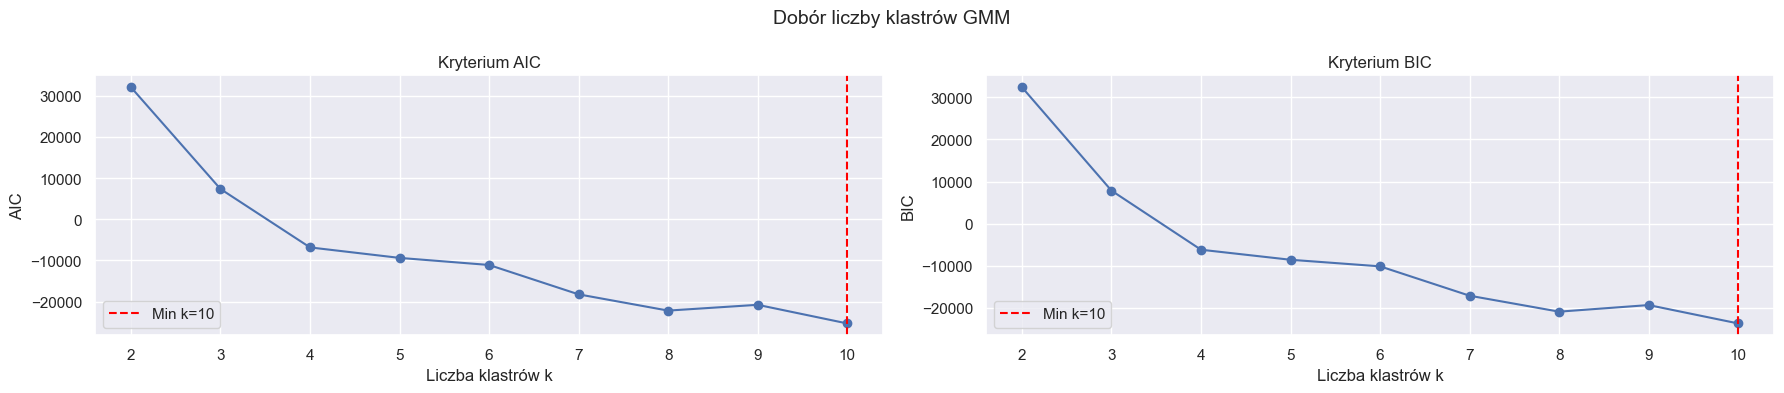

In [270]:
fig, axes = plt.subplots(1, 2, figsize=(18, 4))

for ax, vals, name, k_opt, better in zip(
        axes,
        [aics, bics],
        ['AIC', 'BIC'],
        [k_aic, k_bic],
        ['min', 'min', 'max']):
    ax.plot(list(ks), vals, 'o-')
    ax.axvline(x=k_opt, color='red', linestyle='--',
               label=f'{"Min" if better == "min" else "Max"} k={k_opt}')
    ax.set_title(f'Kryterium {name}')
    ax.set_xlabel('Liczba klastrów k')
    ax.set_ylabel(name)
    ax.legend()

plt.suptitle('Dobór liczby klastrów GMM', fontsize=14)
plt.tight_layout()
plt.show()

## Model GMM

In [271]:
# Dopasowanie finalnego modelu GMM z optymalną liczbą klastrów wg BIC
gmm_final = GaussianMixture(n_components=k_bic, covariance_type='full',
                             random_state=42, n_init=5)
gmm_final.fit(X_scaled)
labels_raw = gmm_final.predict(X_scaled)

# Numerowanie klastrów od 1
df_result = df.copy()
df_result['klaster'] = labels_raw + 1

print(f'Model GMM z k = {k_bic} klastrami.')
counts = df_result['klaster'].value_counts().sort_index()
for k, n in counts.items():
    print(f'  Klaster {k}: {n:>5} produktów ({n/len(df)*100:.1f}%)')

Model GMM z k = 10 klastrami.
  Klaster 1:   290 produktów (12.7%)
  Klaster 2:   664 produktów (29.1%)
  Klaster 3:   139 produktów (6.1%)
  Klaster 4:    95 produktów (4.2%)
  Klaster 5:   168 produktów (7.4%)
  Klaster 6:    63 produktów (2.8%)
  Klaster 7:    39 produktów (1.7%)
  Klaster 8:   257 produktów (11.3%)
  Klaster 9:   427 produktów (18.7%)
  Klaster 10:   137 produktów (6.0%)


## Analiza wyników

In [272]:
# Liczebność i procentowy udział klastrów
counts = df_result['klaster'].value_counts().sort_index()
pct    = (counts / len(df_result) * 100).round(1)
print('Liczebność klastrów:')
for k, n, p in zip(counts.index, counts.values, pct.values):
    print(f'  Klaster {k}: {n:>5} produktów  ({p}%)')

Liczebność klastrów:
  Klaster 1:   290 produktów  (12.7%)
  Klaster 2:   664 produktów  (29.1%)
  Klaster 3:   139 produktów  (6.1%)
  Klaster 4:    95 produktów  (4.2%)
  Klaster 5:   168 produktów  (7.4%)
  Klaster 6:    63 produktów  (2.8%)
  Klaster 7:    39 produktów  (1.7%)
  Klaster 8:   257 produktów  (11.3%)
  Klaster 9:   427 produktów  (18.7%)
  Klaster 10:   137 produktów  (6.0%)


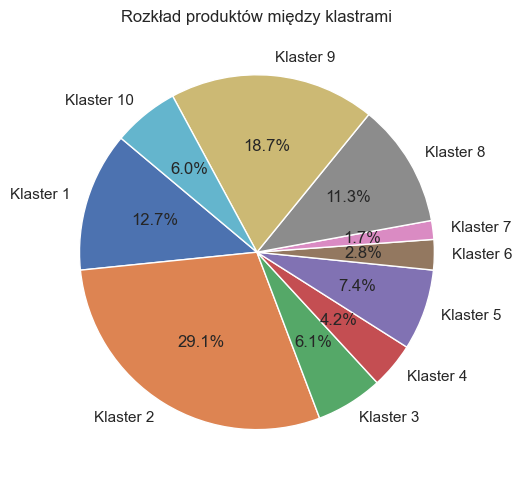

In [273]:
# Wykres kołowy rozkładu produktów między klastrami
fig, ax = plt.subplots(figsize=(7, 5))
ax.pie(counts.values,
       labels=[f'Klaster {k}' for k in counts.index],
       autopct='%1.1f%%',
       startangle=140)
ax.set_title('Rozkład produktów między klastrami')
plt.tight_layout()
plt.show()

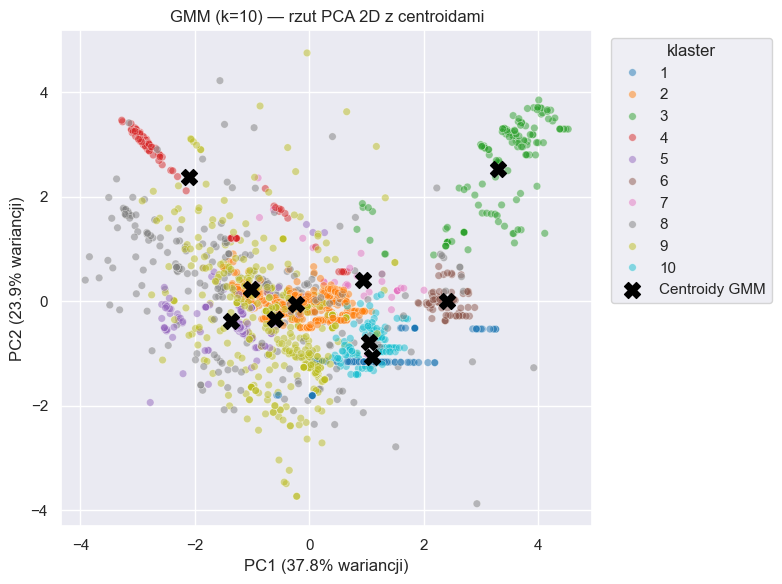

In [274]:
# Rzut PCA 2D z centroidami klastrów zaznaczonymi krzyżykami
pca2 = PCA(n_components=2, random_state=42)
X_vis = pca2.fit_transform(X_scaled)

# Centroidy składowych GMM w przestrzeni PCA
centroids_pca = pca2.transform(gmm_final.means_)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_vis[:, 0], y=X_vis[:, 1], hue=df_result['klaster'],
                palette='tab10', alpha=0.5, s=30, legend='full')
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
            c='black', s=130, marker='X', zorder=5, label='Centroidy GMM')
plt.title(f'GMM (k={k_bic}) — rzut PCA 2D z centroidami')
plt.xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}% wariancji)')
plt.ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}% wariancji)')
plt.legend(title='klaster', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [275]:
# Tabela średnich oryginalnych (nieskodowanych) wartości zmiennych w klastrach
profile = df_result.groupby('klaster')[num_cols].mean().round(2)
print('Średnie wartości zmiennych w klastrach:')
profile.style.background_gradient(cmap='Blues', axis=0)

Średnie wartości zmiennych w klastrach:


,Unitprice,Expire date,Pal grossweight,Pal height,Units per pal,avg_units_per_order
klaster,,,,,,
1,3.790000,523.220000,207.680000,1.020000,0.000000,0.000000
2,2.960000,547.000000,211.640000,1.020000,173.020000,1.620000
3,15.620000,370.240000,612.320000,1.520000,72.300000,1.080000
4,0.370000,518.260000,112.240000,1.500000,1645.260000,93.240000
5,1.600000,730.020000,333.910000,0.940000,901.510000,2.500000
6,18.080000,365.000000,285.310000,0.890000,21.860000,0.730000
7,3.260000,365.000000,229.910000,1.000000,111.510000,6.780000
8,8.300000,547.000000,168.800000,0.960000,2007.460000,26.580000
9,2.800000,547.000000,127.690000,0.940000,1787.380000,10.430000


In [276]:
# Automatyczna charakterystyka klastrów
overall_mean = df_result[num_cols].mean()

print('=== Charakterystyka klastrów ===')
for k in sorted(df_result['klaster'].unique()):
    sub_mean  = df_result[df_result['klaster'] == k][num_cols].mean()
    ratio     = sub_mean / (overall_mean + 1e-9)   # uniknięcie dzielenia przez 0
    top3_high = ratio.nlargest(3).index.tolist()
    top3_low  = ratio.nsmallest(3).index.tolist()
    n = counts[k]
    print(f'\nKlaster {k} (n = {n}):')
    print(f'  Ponadprzeciętne: {", ".join(top3_high)}')
    print(f'  Poniżej średniej: {", ".join(top3_low)}')

=== Charakterystyka klastrów ===

Klaster 1 (n = 290):
  Ponadprzeciętne: Pal height, Expire date, Pal grossweight
  Poniżej średniej: Units per pal, avg_units_per_order, Unitprice

Klaster 2 (n = 664):
  Ponadprzeciętne: Expire date, Pal height, Pal grossweight
  Poniżej średniej: avg_units_per_order, Units per pal, Unitprice

Klaster 3 (n = 139):
  Ponadprzeciętne: Unitprice, Pal grossweight, Pal height
  Poniżej średniej: Units per pal, avg_units_per_order, Expire date

Klaster 4 (n = 95):
  Ponadprzeciętne: avg_units_per_order, Units per pal, Pal height
  Poniżej średniej: Unitprice, Pal grossweight, Expire date

Klaster 5 (n = 168):
  Ponadprzeciętne: Pal grossweight, Expire date, Units per pal
  Poniżej średniej: avg_units_per_order, Unitprice, Pal height

Klaster 6 (n = 63):
  Ponadprzeciętne: Unitprice, Pal grossweight, Pal height
  Poniżej średniej: Units per pal, avg_units_per_order, Expire date

Klaster 7 (n = 39):
  Ponadprzeciętne: Pal grossweight, Pal height, avg_units_pe

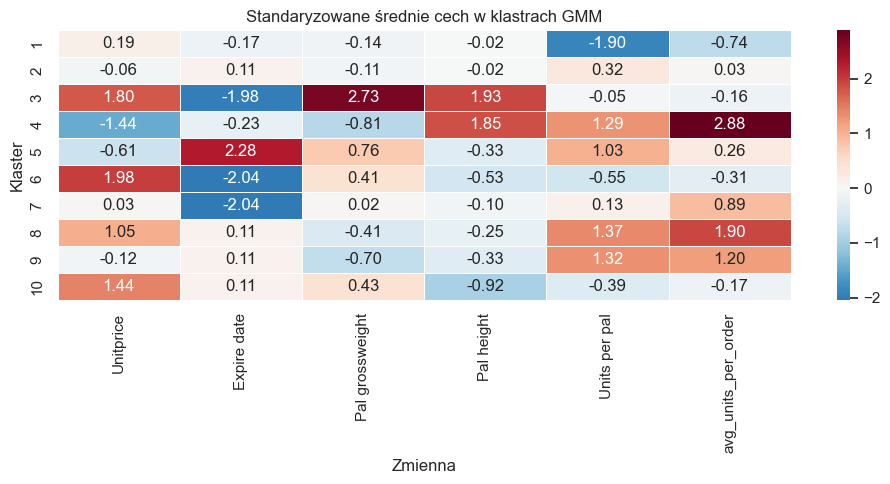

In [277]:
# Heatmapa standaryzowanych średnich klastrów
profile_log = profile.copy()
cols_log = ['Unitprice', 'Units per pal', 'avg_units_per_order']
profile_log[cols_log] = np.log1p(profile_log[cols_log])

profile_std = pd.DataFrame(
    scaler.transform(profile_log[num_cols]),
    index=profile.index,
    columns=num_cols
)

plt.figure(figsize=(10, 5))
sns.heatmap(profile_std, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            linewidths=0.5)
plt.title('Standaryzowane średnie cech w klastrach GMM')
plt.xlabel('Zmienna')
plt.ylabel('Klaster')
plt.tight_layout()
plt.show()

## Raport

### Opis zbioru danych i metodyki

Zbiór danych obejmuje **2 279 produktów magazynowych**. Zawiera 7 zmiennych: cena jednostkowa (`Unitprice`), data ważności (`Expire date`), łączna liczba wysłanych jednostek (`Total outbound`), liczba zamówień wychodzących (`Outbound number`), waga palety (`Pal grossweight`), wysokość palety (`Pal height`), liczba jednostek na palecie (`Units per pal`).

Przed klastrowaniem przeprowadzono następujące kroki przygotowania danych:
- usunięto kolumnę `ID` (identyfikator),
- stworzono zmienną pochodną `avg_units_per_order = Total outbound / (Outbound number + 1)` i usunięto obie oryginalne kolumny (redukcja korelacji 0.86),
- 710 zer w `Unitprice` (31.2% zbioru) zastąpiono medianą wartości dodatnich (2.80) - analiza potwierdziła, że 212 z nich to potwierdzone brakujące wartości (produkty z ceną 0 były wysyłane do klientów), pozostałe 498 to prawdopodobnie produkty bez ceny w systemie,
- zera w `Pal grossweight`, `Pal height` i `Expire date` zastąpiono medianą wartości dodatnich każdej zmiennej - produkt bez wagi, wysokości palety lub terminu ważności fizycznie nie istnieje w systemie, są to braki danych,
- zastosowano `np.log1p` dla `Unitprice`, `Units per pal` i `avg_units_per_order` (prawostronnia skośność),
- przeprowadzono standaryzację (`StandardScaler`).

Do klasteryzacji użyto **Gaussian Mixture Model (GMM)** z pełną macierzą kowariancji (`covariance_type='full'`).

### Wybrana liczba klastrów i sposób jej określenia

Liczbę klastrów wyznaczono na podstawie kryteriów **AIC** i **BIC** dla k od 2 do 10. Oba kryteria zgodnie wskazały **k = 10** jako optymalne. Fakt, że minimum nie wystąpiło wcześniej sugeruje, że dane zawierają wiele subtelnych wzorców logistycznych - różne kombinacje ceny, wymiarów palety, terminu ważności i rotacji tworzą liczne odrębne segmenty produktowe.

### Charakterystyka każdej grupy produktów

| Klaster | n | % | Nazwa opisowa | Główne cechy |
|---------|---|---|---------------|--------------|
| 1 | 290 | 12.7% | Tanie wielkogabarytowe, wolnorotujące | Wysokie i ciężkie palety, długi Expire date, tanie, mało jednostek, niska rotacja |
| 2 | 664 | 29.1% | Tanie masowe, wolnorotujące | Największa grupa; długi Expire date, wysokie i ciężkie palety, tanie, bardzo niska rotacja |
| 3 | 139 | 6.1% | Premium szybko psujące się | Wysoka cena, ciężkie i wysokie palety, **krótki Expire date**, mało jednostek, niska rotacja — ryzyko przeterminowania |
| 4 | 95 | 4.2% | Tanie masowe szybkorotujące | Duże zamówienia, dużo jednostek na palecie, wysoka paleta, tanie, lekkie, krótki Expire date |
| 5 | 168 | 7.4% | Tanie płaskie długoterminowe | Ciężka i niska paleta, dużo jednostek, długi Expire date, tanie, małe zamówienia |
| 6 | 63 | 2.8% | Premium szybko psujące się — wariant | Wysoka cena, ciężkie i wysokie palety, **krótki Expire date**, mało jednostek, niska rotacja |
| 7 | 39 | 1.7% | Wielkogabarytowe szybkorotujące | Bardzo ciężkie i wysokie palety, duże zamówienia objętościowe, krótki Expire date, tanie |
| 8 | 257 | 11.3% | Drogie szybkorotujące | Duże zamówienia, dużo jednostek, wysoka cena, lekka i niska paleta, krótki Expire date |
| 9 | 427 | 18.7% | Tanie szybkorotujące | Dużo jednostek, duże zamówienia, długi Expire date, tanie, lekka i niska paleta |
| 10 | 137 | 6.0% | Drogie wolnorotujące, płaskie | Wysoka cena, ciężka i niska paleta, długi Expire date, mało jednostek, mała rotacja |

*¹ Klastry 1, 3 i 10 mają identyczne cechy dominujące — mogą wskazywać na przesegmentowanie przy k=10.*

### Klaster wymagający największej uwagi logistycznej

**Klastry 3 i 6** (n = 139 + 63 = 202, łącznie 8.9%) — produkty drogie, z ciężkimi i wysokimi paletami, **najkrótszym terminem ważności** i jednocześnie **niską rotacją**. To najbardziej ryzykowny segment: wartościowy towar, który zalega na magazynie i jest bliski przeterminowania. Wymagają ścisłej kontroli i priorytetowego kompletowania.

### Rekomendacje logistyczne

1. **Klastry 1 i 2, tanie wolnorotujące**: strefa głęboka magazynu, regały wysokiego składowania, nie wymagają częstej obsługi.
2. **Klaster 10, drogi wolnorotujący, płaski**: strefa łatwo dostępna z kontrolą dostępu, ścisła ewidencja, monitoring stanów minimalnych - ryzyko zamrożenia kapitału.
3. **Klastry 3 i 6, premium, szybko psujące się**: priorytet, tygodniowy przegląd dat ważności, lokalizacja przy strefie wydań, rozważyć chłodnię jeśli dotyczy produktów spożywczych lub farmaceutycznych.
4. **Klastry 8 i 9, szybkorotujące**: strefa pakowania blisko doków załadunkowych, automatyzacja kompletacji, wysoka dostępność regałów.
5. **Klaster 4, tanie masowe szybkorotujące**: duże powierzchnie odkładcze, obsługa wózkiem widłowym, optymalizacja tras kompletacji.
6. **Klaster 5, tanie płaskie długoterminowe**: regały niskie, kompletacja ręczna, niska priorytetowość operacyjna.
7. **Klaster 7, wielkogabarytowe szybkorotujące**: dedykowana strefa z dostępem wózka widłowego, priorytet przy dokowaniu ze względu na krótki termin ważności.
8. **Monitoring**: segmentację aktualizować co kwartał, sezonowość wpływa na rotację i może przesuwać produkty między klastrami.